# Week 6 Assignment -- Autoencoder for Image Denoising

**Name:** Sahil Yadav

**Objective:** Build a deep learning model that removes noise from images using autoencoders on MNIST.

We implement and compare three architectures:
1. Fully Connected Autoencoder
2. Convolutional Autoencoder (Upsampling)
3. Convolutional Autoencoder (Transpose Convolutions)

---

## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

TensorFlow: 2.21.0


GPU: False


## 2. Load & Explore MNIST

Train: (60000, 28, 28)  Test: (10000, 28, 28)
Pixel range: [0, 255]


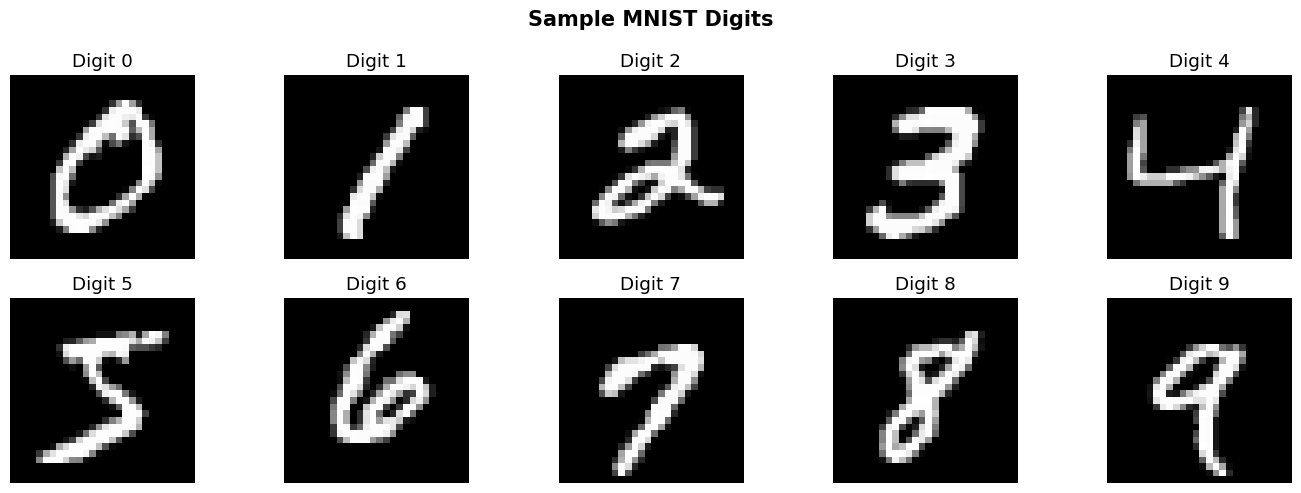

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f'Train: {x_train.shape}  Test: {x_test.shape}')
print(f'Pixel range: [{x_train.min()}, {x_train.max()}]')

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle('Sample MNIST Digits', fontsize=15, fontweight='bold')
for d in range(10):
    ax = axes[d//5, d%5]
    ax.imshow(x_train[np.where(y_train==d)[0][0]], cmap='gray')
    ax.set_title(f'Digit {d}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 3. Preprocessing & Noise Addition

In [3]:
# Normalize and reshape
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

NOISE_FACTOR = 0.5

def add_noise(images, nf=NOISE_FACTOR):
    return np.clip(images + nf * np.random.normal(size=images.shape), 0., 1.)

x_train_noisy = add_noise(x_train)
x_test_noisy  = add_noise(x_test)

print(f'Train shape: {x_train.shape}  Noisy range: [{x_train_noisy.min():.2f}, {x_train_noisy.max():.2f}]')

Train shape: (60000, 28, 28, 1)  Noisy range: [0.00, 1.00]


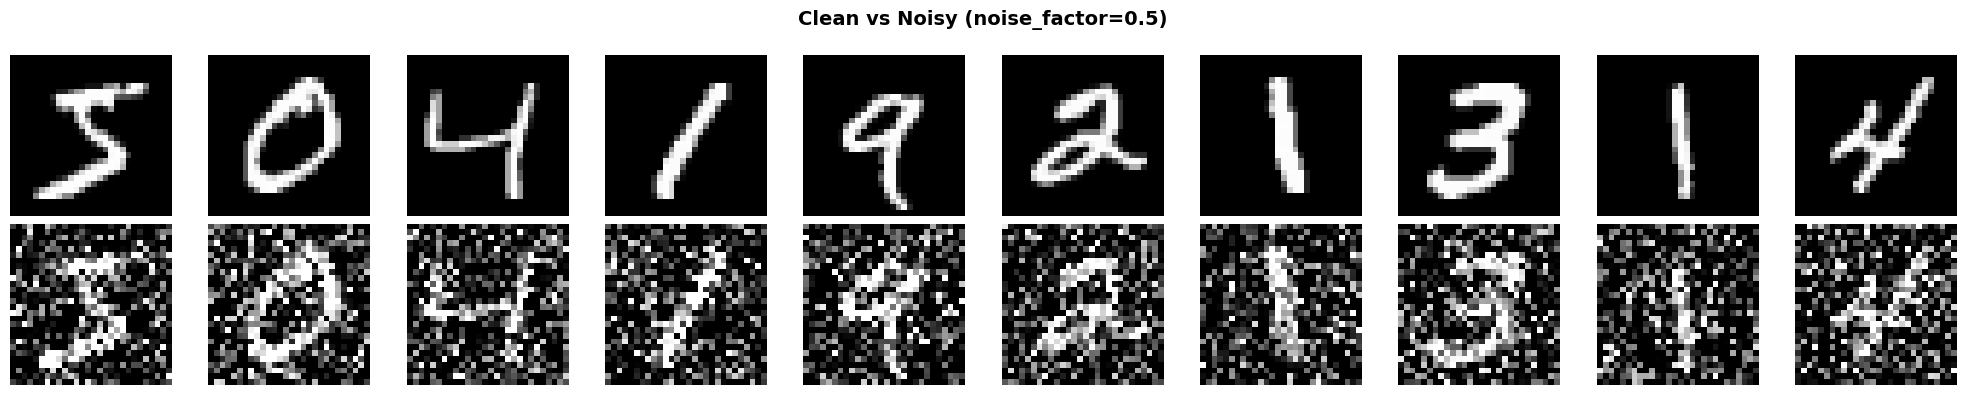

In [4]:
# Visualize clean vs noisy
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle('Clean vs Noisy (noise_factor=0.5)', fontsize=14, fontweight='bold')
for i in range(10):
    axes[0,i].imshow(x_train[i].reshape(28,28), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(x_train_noisy[i].reshape(28,28), cmap='gray'); axes[1,i].axis('off')
axes[0,0].set_ylabel('Clean', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Noisy', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. What is an Autoencoder?

An **autoencoder** is a neural network that learns to compress input data into a compact **latent representation** and then reconstruct the original input from it.

```
Input (28x28) --> [Encoder] --> Latent Code (compressed) --> [Decoder] --> Output (28x28)
```

| Component | Role |
|-----------|------|
| **Encoder** | Compresses input to latent space |
| **Bottleneck** | Compact latent representation |
| **Decoder** | Reconstructs input from latent space |

### Denoising Autoencoder

A **Denoising Autoencoder** receives **noisy** input but is trained to output the **clean** original. This forces it to learn robust features that ignore noise:

$$\mathcal{L} = \| x_{clean} - \text{Decoder}(\text{Encoder}(x_{noisy})) \|^2$$

### Our 3 Architectures

| # | Architecture | Decoder Method | Key Trait |
|---|-------------|----------------|----------|
| 1 | Fully Connected | Dense layers | Simple, loses spatial info |
| 2 | Conv + Upsampling | UpSampling2D (interpolation) | Preserves spatial structure |
| 3 | Conv + Transpose | Conv2DTranspose (learned) | Sharpest reconstruction |

## 5. Model 1 -- Fully Connected Autoencoder

- Encoder: 784 -> 512 -> 256 -> 128 -> 32
- Decoder: 32 -> 128 -> 256 -> 512 -> 784

In [5]:
class FCAutoencoder(Model):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = Sequential([
            layers.Flatten(input_shape=(28,28,1)),
            layers.Dense(512, activation='relu'), layers.BatchNormalization(),
            layers.Dense(256, activation='relu'), layers.BatchNormalization(),
            layers.Dense(128, activation='relu'), layers.BatchNormalization(),
            layers.Dense(latent_dim, activation='relu'),
        ], name='fc_encoder')
        self.decoder = Sequential([
            layers.Dense(128, activation='relu', input_shape=(latent_dim,)),
            layers.BatchNormalization(),
            layers.Dense(256, activation='relu'), layers.BatchNormalization(),
            layers.Dense(512, activation='relu'), layers.BatchNormalization(),
            layers.Dense(784, activation='sigmoid'),
            layers.Reshape((28,28,1)),
        ], name='fc_decoder')
    def call(self, x):
        return self.decoder(self.encoder(x))

fc_ae = FCAutoencoder()
fc_ae.compile(optimizer='adam', loss='mse')
_ = fc_ae(x_train[:1])
print(f'FC Autoencoder  |  Encoder out: {fc_ae.encoder(x_train[:1]).shape}  |  Decoder out: {fc_ae(x_train[:1]).shape}')
fc_ae.summary()

FC Autoencoder  |  Encoder out: (1, 32)  |  Decoder out: (1, 28, 28, 1)


Model: "fc_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc_encoder (Sequential)         │ (None, 32)             │       573,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_decoder (Sequential)         │ (None, 28, 28, 1)      │       574,608 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,464 (4.38 MB)

 Trainable params: 1,144,880 (4.37 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [6]:
print('Training FC Autoencoder...')
fc_hist = fc_ae.fit(
    x_train_noisy, x_train, epochs=25, batch_size=256, shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[EarlyStopping('val_loss', patience=5, restore_best_weights=True, verbose=1),
               ReduceLROnPlateau('val_loss', factor=0.5, patience=3, verbose=1)],
    verbose=1
)
print(f'Best val loss: {min(fc_hist.history["val_loss"]):.6f}')

Training FC Autoencoder...


Epoch 1/25


  1/235 ━━━━━━━━━━━━━━━━━━━━ 23:32 6s/step - loss: 0.2313

  4/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.2281 

  7/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.2155

...

232/235 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0135

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0135

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0134 - val_loss: 0.0167 - learning_rate: 5.0000e-04


Restoring model weights from the end of the best epoch: 25.


Best val loss: 0.016667


## 6. Model 2 -- Convolutional Autoencoder (Upsampling)

- Encoder: 28x28 -> Conv+Pool -> 14x14 -> Conv+Pool -> 7x7
- Decoder: 7x7 -> Conv+UpSample -> 14x14 -> Conv+UpSample -> 28x28

In [7]:
def build_conv_upsample():
    """Conv autoencoder with UpSampling2D. Dims: 28->14->7->14->28."""
    inp = layers.Input(shape=(28,28,1))
    
    # Encoder
    x = layers.Conv2D(32,(3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32,(3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)                               # 28->14
    x = layers.Conv2D(64,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64,(3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2,2))(x)                         # 14->7
    
    # Decoder
    x = layers.Conv2D(64,(3,3), activation='relu', padding='same')(encoded)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2,2))(x)                               # 7->14
    x = layers.Conv2D(32,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2,2))(x)                               # 14->28
    out = layers.Conv2D(1,(3,3), activation='sigmoid', padding='same')(x)
    
    return Model(inp, out, name='conv_upsample_ae')

conv_up_ae = build_conv_upsample()
conv_up_ae.compile(optimizer='adam', loss='mse')
print(f'Conv+Upsample AE  |  Output: {conv_up_ae.output_shape}  |  Params: {conv_up_ae.count_params():,}')
conv_up_ae.summary()

Conv+Upsample AE  |  Output: (None, 28, 28, 1)  |  Params: 121,441


Model: "conv_upsample_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,441 (474.38 KB)

 Trainable params: 121,057 (472.88 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
print('Training Conv+Upsample Autoencoder...')
conv_up_hist = conv_up_ae.fit(
    x_train_noisy, x_train, epochs=25, batch_size=256, shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[EarlyStopping('val_loss', patience=5, restore_best_weights=True, verbose=1),
               ReduceLROnPlateau('val_loss', factor=0.5, patience=3, verbose=1)],
    verbose=1
)
print(f'Best val loss: {min(conv_up_hist.history["val_loss"]):.6f}')

Training Conv+Upsample Autoencoder...


Epoch 1/25


  1/235 ━━━━━━━━━━━━━━━━━━━━ 48:14 12s/step - loss: 0.3229

  2/235 ━━━━━━━━━━━━━━━━━━━━ 1:14 318ms/step - loss: 0.2974

  3/235 ━━━━━━━━━━━━━━━━━━━━ 1:13 317ms/step - loss: 0.2798

...

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 0.0091


Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


235/235 ━━━━━━━━━━━━━━━━━━━━ 55s 232ms/step - loss: 0.0091 - val_loss: 0.0096 - learning_rate: 2.5000e-04


Restoring model weights from the end of the best epoch: 25.


Best val loss: 0.009572


## 7. Model 3 -- Convolutional Autoencoder (Transpose Conv)

- Encoder: Conv(stride=2) for downsampling: 28->14->7
- Decoder: Conv2DTranspose(stride=2) for learnable upsampling: 7->14->28

In [9]:
def build_conv_transpose():
    """Conv autoencoder with Conv2DTranspose. Dims: 28->14->7->14->28."""
    inp = layers.Input(shape=(28,28,1))
    
    # Encoder (strided conv downsampling)
    x = layers.Conv2D(32,(3,3), activation='relu', strides=2, padding='same')(inp)  # 28->14
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64,(3,3), activation='relu', strides=2, padding='same')(x)    # 14->7
    x = layers.BatchNormalization()(x)
    encoded = layers.Conv2D(64,(3,3), activation='relu', padding='same')(x)
    
    # Decoder (transpose conv upsampling)
    x = layers.Conv2DTranspose(32,(3,3), activation='relu', strides=2, padding='same')(encoded)  # 7->14
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32,(3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(16,(3,3), activation='relu', strides=2, padding='same')(x)  # 14->28
    x = layers.BatchNormalization()(x)
    out = layers.Conv2D(1,(3,3), activation='sigmoid', padding='same')(x)
    
    return Model(inp, out, name='conv_transpose_ae')

conv_tr_ae = build_conv_transpose()
conv_tr_ae.compile(optimizer='adam', loss='mse')
print(f'Conv+Transpose AE  |  Output: {conv_tr_ae.output_shape}  |  Params: {conv_tr_ae.count_params():,}')
conv_tr_ae.summary()

Conv+Transpose AE  |  Output: (None, 28, 28, 1)  |  Params: 98,305


Model: "conv_transpose_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,305 (384.00 KB)

 Trainable params: 97,889 (382.38 KB)

 Non-trainable params: 416 (1.62 KB)

In [10]:
print('Training Conv+Transpose Autoencoder...')
conv_tr_hist = conv_tr_ae.fit(
    x_train_noisy, x_train, epochs=25, batch_size=256, shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[EarlyStopping('val_loss', patience=5, restore_best_weights=True, verbose=1),
               ReduceLROnPlateau('val_loss', factor=0.5, patience=3, verbose=1)],
    verbose=1
)
print(f'Best val loss: {min(conv_tr_hist.history["val_loss"]):.6f}')

Training Conv+Transpose Autoencoder...


Epoch 1/25


  1/235 ━━━━━━━━━━━━━━━━━━━━ 21:41 6s/step - loss: 0.2872

  2/235 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - loss: 0.2792

  3/235 ━━━━━━━━━━━━━━━━━━━━ 26s 115ms/step - loss: 0.2716

...

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0088


Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - loss: 0.0088 - val_loss: 0.0093 - learning_rate: 2.5000e-04


Restoring model weights from the end of the best epoch: 25.


Best val loss: 0.009331


## 8. Model Comparison & Evaluation

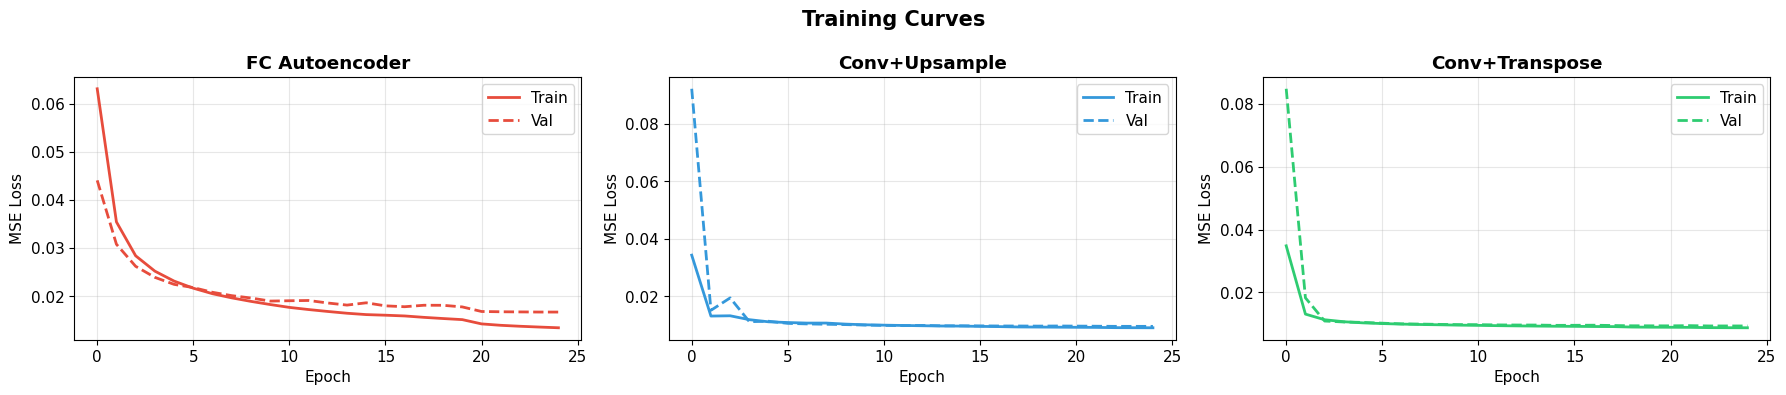

In [11]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, (name, h, c) in enumerate([
    ('FC Autoencoder', fc_hist, '#e74c3c'),
    ('Conv+Upsample', conv_up_hist, '#3498db'),
    ('Conv+Transpose', conv_tr_hist, '#2ecc71')]):
    axes[i].plot(h.history['loss'], label='Train', color=c, lw=2)
    axes[i].plot(h.history['val_loss'], label='Val', color=c, lw=2, ls='--')
    axes[i].set_title(name, fontweight='bold'); axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MSE Loss'); axes[i].legend(); axes[i].grid(alpha=0.3)
plt.suptitle('Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

In [12]:
def eval_model(model, x_noisy, x_clean, name):
    pred = model.predict(x_noisy, verbose=0)
    mse = np.mean((x_clean - pred)**2)
    p = np.mean([psnr(x_clean[i,:,:,0], pred[i,:,:,0], data_range=1.) for i in range(1000)])
    s = np.mean([ssim(x_clean[i,:,:,0], pred[i,:,:,0], data_range=1.) for i in range(1000)])
    return {'Model':name, 'MSE':mse, 'PSNR':p, 'SSIM':s}, pred

# Baseline
n_mse = np.mean((x_test - x_test_noisy)**2)
n_psnr = np.mean([psnr(x_test[i,:,:,0], x_test_noisy[i,:,:,0], data_range=1.) for i in range(1000)])
n_ssim = np.mean([ssim(x_test[i,:,:,0], x_test_noisy[i,:,:,0], data_range=1.) for i in range(1000)])

r1, p1 = eval_model(fc_ae, x_test_noisy, x_test, 'FC Autoencoder')
r2, p2 = eval_model(conv_up_ae, x_test_noisy, x_test, 'Conv+Upsample')
r3, p3 = eval_model(conv_tr_ae, x_test_noisy, x_test, 'Conv+Transpose')

print(f'{"Model":<22} {"MSE":>10} {"PSNR(dB)":>10} {"SSIM":>10}')
print('='*54)
print(f'{"Noisy (baseline)":<22} {n_mse:>10.6f} {n_psnr:>10.2f} {n_ssim:>10.4f}')
print('-'*54)
for r in [r1, r2, r3]:
    print(f'{r["Model"]:<22} {r["MSE"]:>10.6f} {r["PSNR"]:>10.2f} {r["SSIM"]:>10.4f}')

Model                         MSE   PSNR(dB)       SSIM
Noisy (baseline)         0.115483       9.39     0.3616
------------------------------------------------------
FC Autoencoder           0.016667      18.19     0.7979
Conv+Upsample            0.009572      20.59     0.8588
Conv+Transpose           0.009331      20.72     0.8656


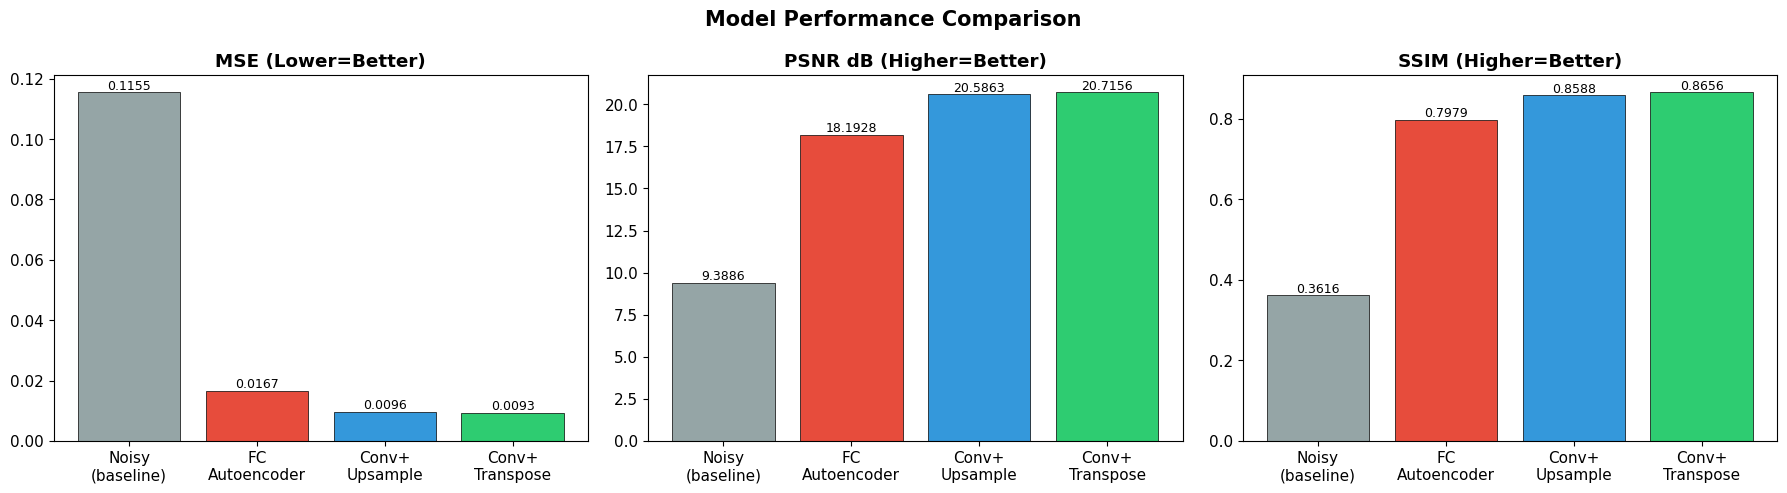

In [13]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
names = ['Noisy\n(baseline)', 'FC\nAutoencoder', 'Conv+\nUpsample', 'Conv+\nTranspose']
clrs = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']

for ax, title, vals in [
    (axes[0], 'MSE (Lower=Better)', [n_mse, r1['MSE'], r2['MSE'], r3['MSE']]),
    (axes[1], 'PSNR dB (Higher=Better)', [n_psnr, r1['PSNR'], r2['PSNR'], r3['PSNR']]),
    (axes[2], 'SSIM (Higher=Better)', [n_ssim, r1['SSIM'], r2['SSIM'], r3['SSIM']])]:
    bars = ax.bar(names, vals, color=clrs, edgecolor='black', lw=0.5)
    ax.set_title(title, fontweight='bold')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:.4f}',
                ha='center', va='bottom', fontsize=9)
plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Denoising Results Visualization

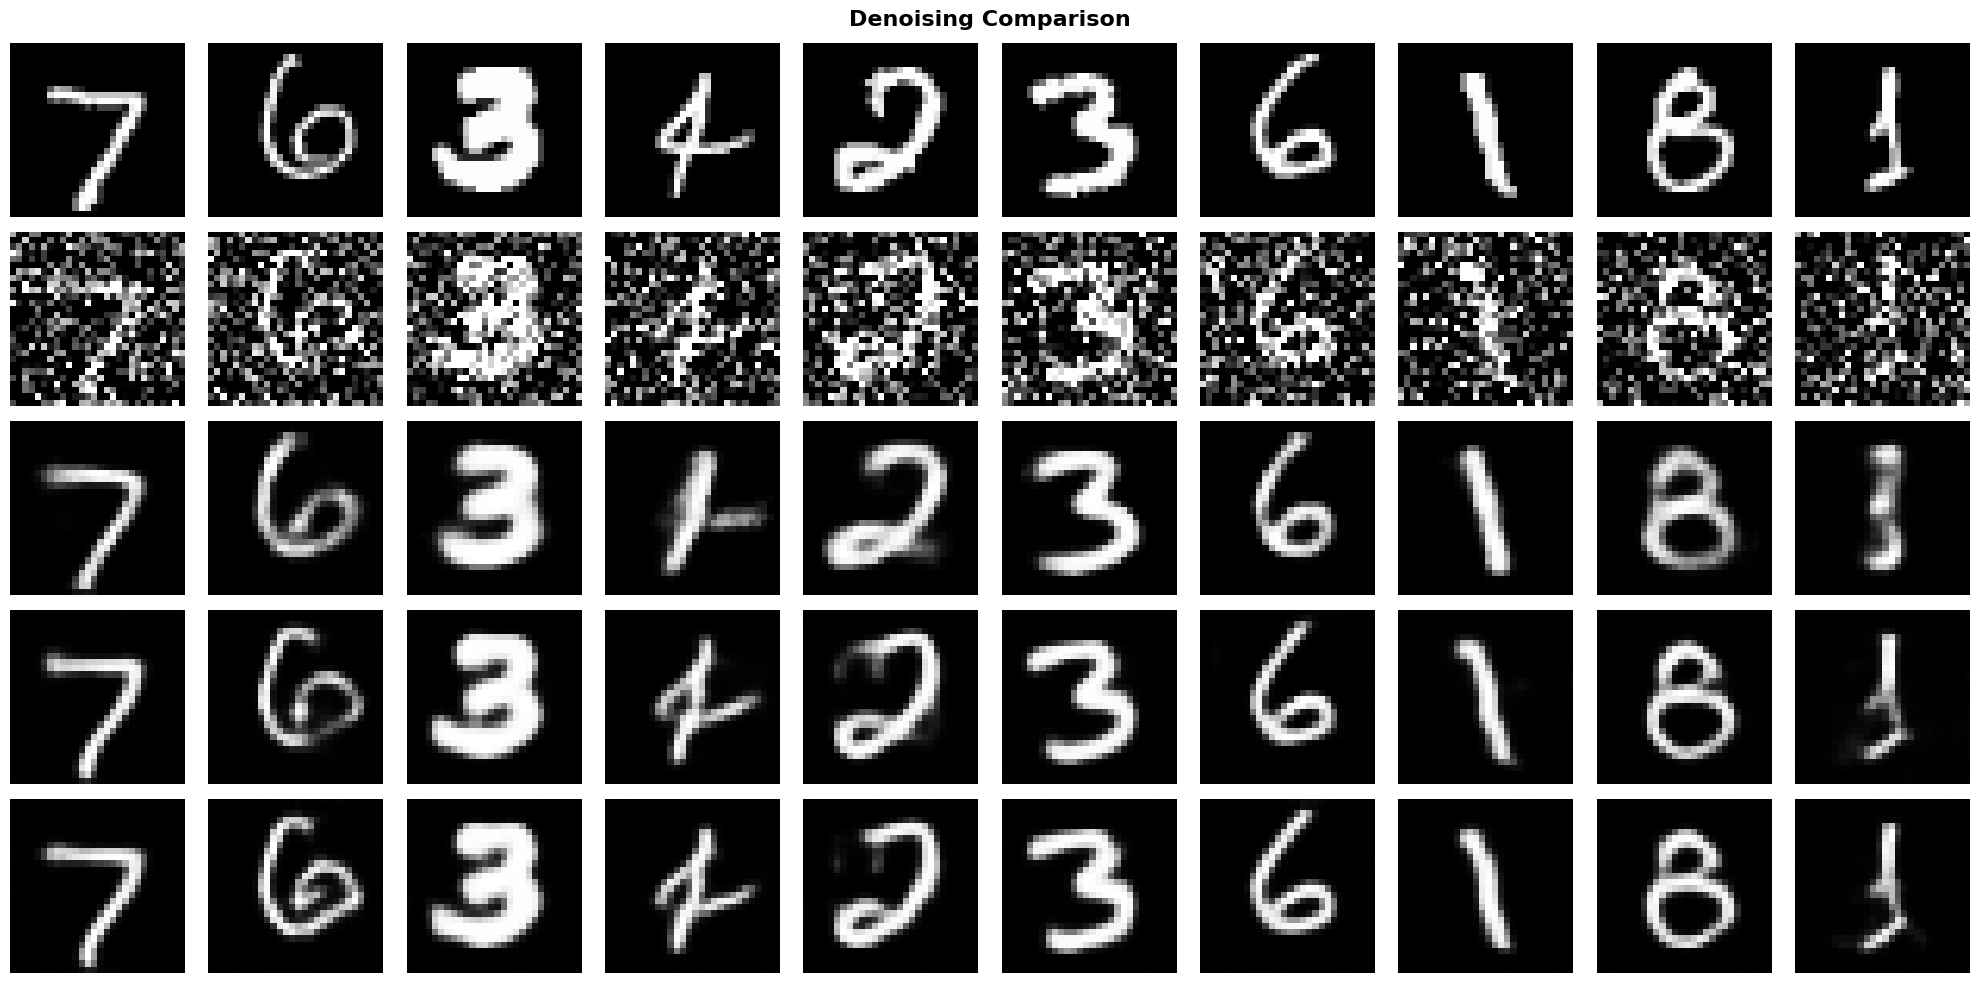

In [14]:
n = 10
fig, axes = plt.subplots(5, n, figsize=(20, 10))
labels = ['Original', 'Noisy', 'FC Denoised', 'Conv+Up Denoised', 'Conv+Tr Denoised']
preds = [None, None, p1, p2, p3]

for i in range(n):
    idx = i * 100
    axes[0,i].imshow(x_test[idx,:,:,0], cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(x_test_noisy[idx,:,:,0], cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(p1[idx,:,:,0], cmap='gray'); axes[2,i].axis('off')
    axes[3,i].imshow(p2[idx,:,:,0], cmap='gray'); axes[3,i].axis('off')
    axes[4,i].imshow(p3[idx,:,:,0], cmap='gray'); axes[4,i].axis('off')

for j, lbl in enumerate(labels):
    axes[j,0].set_ylabel(lbl, fontsize=11, fontweight='bold', rotation=0, labelpad=100, va='center')
plt.suptitle('Denoising Comparison', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

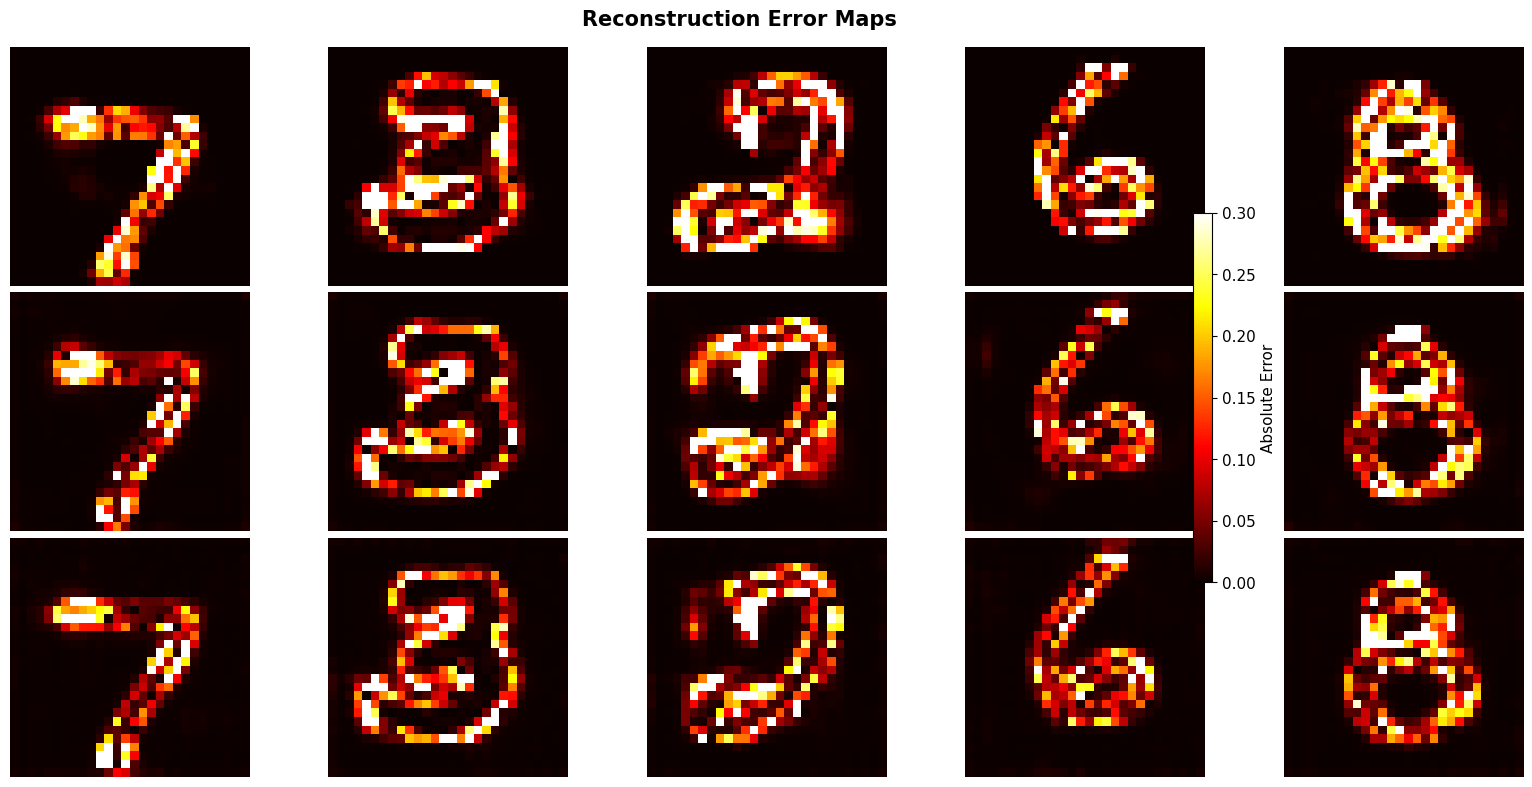

In [15]:
# Error maps
fig, axes = plt.subplots(3, 5, figsize=(16, 8))
for row, (nm, pred) in enumerate([('FC', p1), ('Conv+Up', p2), ('Conv+Tr', p3)]):
    for col in range(5):
        idx = col * 200
        diff = np.abs(x_test[idx,:,:,0] - pred[idx,:,:,0])
        im = axes[row,col].imshow(diff, cmap='hot', vmin=0, vmax=0.3)
        axes[row,col].axis('off')
        if col == 0:
            axes[row,col].set_ylabel(nm, fontsize=12, fontweight='bold', rotation=0, labelpad=60, va='center')
fig.colorbar(im, ax=axes, shrink=0.6, label='Absolute Error')
plt.suptitle('Reconstruction Error Maps', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Latent Space Visualization

Latent shape: (5000, 32)
Running t-SNE...


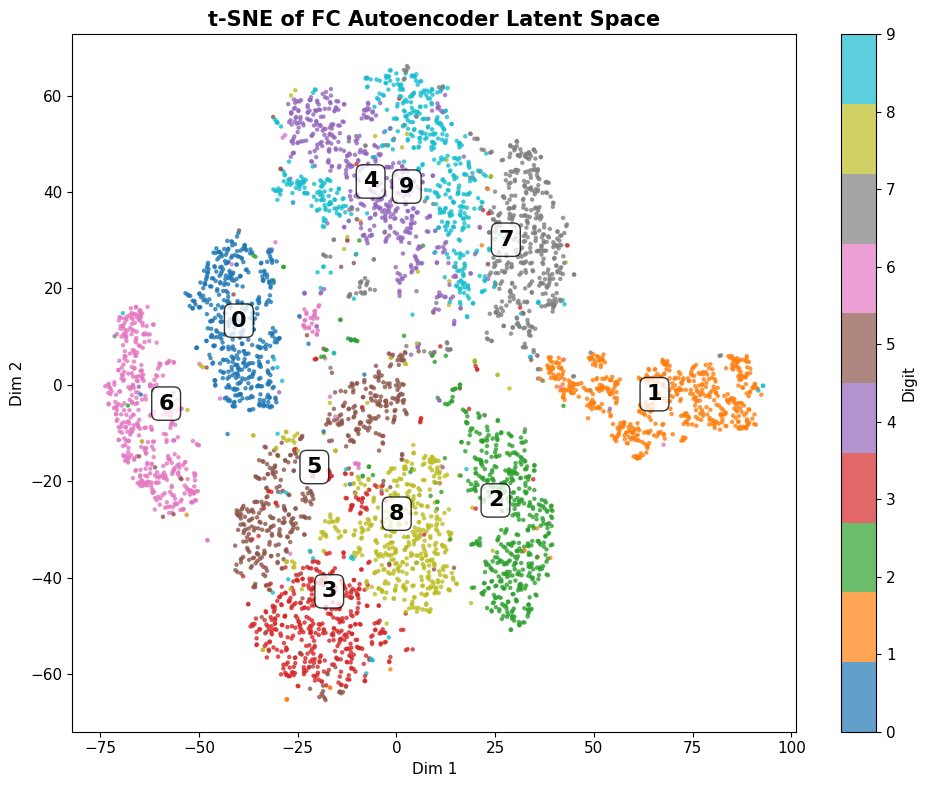

In [16]:
from sklearn.manifold import TSNE

n_tsne = 5000
latent = fc_ae.encoder.predict(x_test[:n_tsne], verbose=0)
print(f'Latent shape: {latent.shape}')

print('Running t-SNE...')
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(latent)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_2d[:,0], tsne_2d[:,1], c=y_test[:n_tsne], cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, label='Digit')
plt.title('t-SNE of FC Autoencoder Latent Space', fontsize=15, fontweight='bold')
plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
for d in range(10):
    c = tsne_2d[y_test[:n_tsne]==d].mean(axis=0)
    plt.annotate(str(d), c, fontsize=16, fontweight='bold', ha='center',
                 bbox=dict(boxstyle='round', fc='white', alpha=0.8))
plt.tight_layout(); plt.show()

## 11. Conclusion

1. All three autoencoders successfully denoise MNIST images, significantly outperforming the noisy baseline.
2. **Convolutional models outperform FC** because they preserve spatial structure.
3. **Conv+Transpose slightly edges out Conv+Upsample** thanks to learnable upsampling vs fixed interpolation.
4. The FC model produces slightly blurrier outputs due to loss of 2D spatial information from flattening.
5. t-SNE of the latent space confirms the encoder learns meaningful digit-specific features even from noisy inputs.